## Setup

### Install Required Packages

In [1]:
!pip install pyspark py4j matplotlib

### Initialize Spark Session and Load Data

In [2]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql.functions import col, sum as spark_sum, year, month, weekofyear, to_date, date_trunc, concat, lit, lpad, row_number, split, when
from pyspark.sql.window import Window
from datetime import datetime, timedelta

# Create Spark Session
spark = SparkSession.builder \
    .appName("NBA Player & Team Analysis") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

# Load datasets
base_path = "nba-stats/"

players_df = spark.read.csv(base_path + "Players.csv", header=True, inferSchema=True)
player_stats_df = spark.read.csv(base_path + "PlayerStatistics.csv", header=True, inferSchema=True)
team_histories_df = spark.read.csv(base_path + "TeamHistories.csv", header=True, inferSchema=True)
team_stats_df = spark.read.csv(base_path + "TeamStatistics.csv", header=True, inferSchema=True)

print("\nDatasets loaded successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/15 21:32:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/15 21:32:06 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.0.1



Datasets loaded successfully!


## Player Point History

Visualize a player's scoring history over time with customizable aggregation.

In [3]:
def get_player_point_history(player, numPastSeasons, games_per_point=1, show_home=True, show_away=True):
    """
    Generate a graph of player's scoring history over the specified number of past seasons.
    
    Parameters:
    -----------
    player : str
        Player name to search for (first name, last name, or full name)
    numPastSeasons : int
        Number of past seasons to include in the analysis
    games_per_point : int
        Number of games to aggregate per data point (default: 1)
        - 1 = each point represents a single game
        - 2 = each point represents sum of 2 consecutive games
        - 5 = each point represents sum of 5 consecutive games
    show_home : bool
        If True, show home games on the graph (default: True)
    show_away : bool
        If True, show away games on the graph (default: True)
    
    Returns:
    --------
    matplotlib figure showing the point history
    """
    
    if not show_home and not show_away:
        print("Error: At least one of show_home or show_away must be True")
        return None
    
    # Create a full name column for searching
    players_with_fullname = players_df.withColumn(
        "fullName", 
        concat(col("firstName"), lit(" "), col("lastName"))
    )
    
    # Get player ID from players dataframe
    player_info = players_with_fullname.filter(
        (col("firstName").like(f"%{player}%")) | 
        (col("lastName").like(f"%{player}%")) |
        (col("fullName").like(f"%{player}%"))
    ).first()
    
    if not player_info:
        print(f"Player '{player}' not found in database.")
        return None
    
    player_id = player_info["personId"]
    player_name = f"{player_info['firstName']} {player_info['lastName']}"
    
    print(f"Found player: {player_name} (ID: {player_id})")
    
    # Calculate the cutoff date for seasons
    current_year = datetime.now().year
    cutoff_year = current_year - numPastSeasons
    
    # Filter player statistics
    player_games = player_stats_df.filter(col("personId") == player_id) \
        .select("gameDate", "points", "home", "numMinutes")
    
    # Convert numMinutes to decimal format
    player_games = player_games.withColumn(
        "minutes_decimal",
        when(col("numMinutes").contains(":"),
             split(col("numMinutes"), ":")[0].cast("double") + 
             (split(col("numMinutes"), ":")[1].cast("double") / 60)
        ).otherwise(col("numMinutes").cast("double"))
    )
    
    # Convert gameDate to date type
    player_games = player_games.withColumn("gameDate", to_date(col("gameDate")))
    
    # Filter by date and games played
    cutoff_date = datetime(cutoff_year, 1, 1)
    player_games = player_games.filter(
        (col("gameDate") >= cutoff_date) &
        (col("minutes_decimal").isNotNull()) & 
        (col("minutes_decimal") > 0) &
        (col("points").isNotNull())
    ).orderBy("gameDate")
    
    # Separate home and away games
    home_games = player_games.filter(col("home") == 1).orderBy("gameDate") if show_home else None
    away_games = player_games.filter(col("home") == 0).orderBy("gameDate") if show_away else None
    
    # Convert to Pandas
    home_df = home_games.toPandas() if home_games is not None else None
    away_df = away_games.toPandas() if away_games is not None else None
    
    if (home_df is None or home_df.empty) and (away_df is None or away_df.empty):
        print(f"No data found for {player_name} in the last {numPastSeasons} seasons.")
        return None
    
    # Aggregate by games_per_point
    def aggregate_games(df, games_per_point):
        if df is None or df.empty:
            return df
        df['game_group'] = df.index // games_per_point
        aggregated = df.groupby('game_group').agg({
            'points': 'sum',
            'gameDate': 'last'
        }).reset_index()
        return aggregated
    
    home_agg = aggregate_games(home_df, games_per_point) if home_df is not None else None
    away_agg = aggregate_games(away_df, games_per_point) if away_df is not None else None
    
    # Print stats
    home_count = len(home_agg) if home_agg is not None and not home_agg.empty else 0
    away_count = len(away_agg) if away_agg is not None and not away_agg.empty else 0
    
    if show_home and show_away:
        print(f"Found {home_count} home and {away_count} away data points for {player_name}")
    elif show_home:
        print(f"Found {home_count} home data points for {player_name}")
    else:
        print(f"Found {away_count} away data points for {player_name}")
    print(f"(Aggregated by {games_per_point} game(s) per point)")
    print("(Excluding games with 0 minutes played)")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    if show_home and home_agg is not None and not home_agg.empty:
        ax.plot(home_agg['gameDate'], home_agg['points'], 
               marker='o', markersize=4, linestyle='', alpha=0.7, 
               label='Home', color='blue')
    
    if show_away and away_agg is not None and not away_agg.empty:
        ax.plot(away_agg['gameDate'], away_agg['points'], 
               marker='s', markersize=4, linestyle='', alpha=0.7, 
               label='Away', color='red')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha='right')
    
    # Add statistics
    total_home = home_agg['points'].sum() if home_agg is not None and not home_agg.empty else 0
    total_away = away_agg['points'].sum() if away_agg is not None and not away_agg.empty else 0
    avg_home = home_agg['points'].mean() if home_agg is not None and not home_agg.empty else 0
    avg_away = away_agg['points'].mean() if away_agg is not None and not away_agg.empty else 0
    
    if show_home and show_away:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f}) | Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    elif show_home:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f})'
    else:
        stats_text = f'Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    if show_home and show_away:
        ax.legend(loc='upper right')
    
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Points', fontsize=12, fontweight='bold')
    
    game_label = "game" if games_per_point == 1 else f"{games_per_point} games"
    
    if show_home and show_away:
        title_suffix = " (Home vs Away)"
    elif show_home:
        title_suffix = " (Home Only)"
    else:
        title_suffix = " (Away Only)"
    
    ax.set_title(f'{player_name} - Point History (Per {game_label} - Last {numPastSeasons} Seasons){title_suffix}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("Function 'get_player_point_history' is now available!")

Function 'get_player_point_history' is now available!


### Player Point History Examples

Found player: LeBron James (ID: 2544)


Found 142 home and 132 away data points for LeBron James
(Aggregated by 1 game(s) per point)
(Excluding games with 0 minutes played)


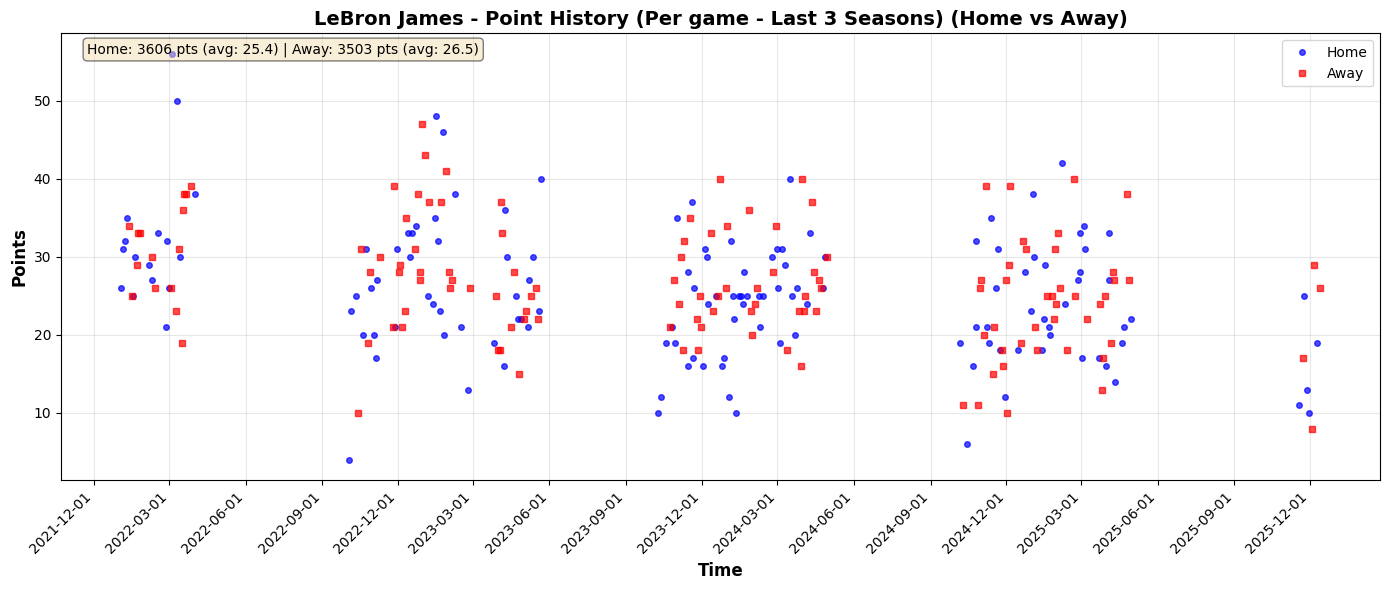

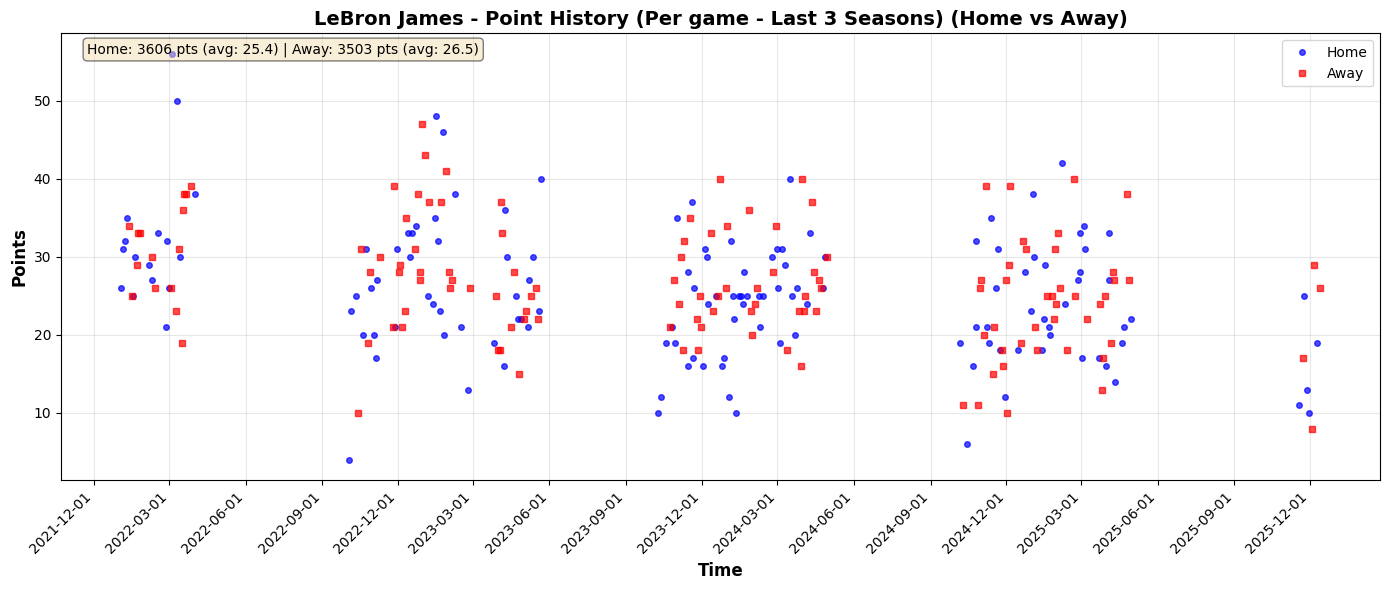

In [4]:
# Example: LeBron James - last 3 seasons, home and away
get_player_point_history("LeBron James", 3, games_per_point=1, show_home=True, show_away=True)

## Team Point History

Visualize a team's scoring history over time.

In [5]:
def get_team_point_history(team, numPastSeasons, games_per_point=1, show_home=True, show_away=True):
    """
    Generate a graph of team's scoring history over the specified number of past seasons.
    
    Parameters:
    -----------
    team : str
        Team name or abbreviation to search for (e.g., "Lakers", "LAL")
    numPastSeasons : int
        Number of past seasons to include in the analysis
    games_per_point : int
        Number of games to aggregate per data point (default: 1)
    show_home : bool
        If True, show home games on the graph (default: True)
    show_away : bool
        If True, show away games on the graph (default: True)
    
    Returns:
    --------
    matplotlib figure showing the point history
    """
    
    if not show_home and not show_away:
        print("Error: At least one of show_home or show_away must be True")
        return None
    
    # Search for team
    matching_teams = team_histories_df.filter(
        (col("teamName").like(f"%{team}%")) | 
        (col("teamAbbrev").like(f"%{team}%")) |
        (col("teamCity").like(f"%{team}%"))
    ).orderBy(col("seasonActiveTill").desc_nulls_first())
    
    team_info = matching_teams.first()
    
    if not team_info:
        print(f"Team '{team}' not found in database.")
        return None
    
    team_id = team_info["teamId"]
    team_name = f"{team_info['teamCity']} {team_info['teamName']}"
    
    print(f"Found team: {team_name} (ID: {team_id})")
    
    # Calculate cutoff date
    current_year = datetime.now().year
    cutoff_year = current_year - numPastSeasons
    cutoff_date = datetime(cutoff_year, 1, 1)
    
    # Filter team statistics
    team_games = team_stats_df.filter(col("teamId") == team_id) \
        .select("gameDate", "teamScore", "home") \
        .withColumnRenamed("teamScore", "points") \
        .withColumn("gameDate", to_date(col("gameDate"))) \
        .filter(
            (col("gameDate") >= cutoff_date) &
            (col("points").isNotNull())
        ).orderBy("gameDate")
    
    # Separate home and away games
    home_games = team_games.filter(col("home") == 1).orderBy("gameDate") if show_home else None
    away_games = team_games.filter(col("home") == 0).orderBy("gameDate") if show_away else None
    
    # Convert to Pandas
    home_df = home_games.toPandas() if home_games is not None else None
    away_df = away_games.toPandas() if away_games is not None else None
    
    if (home_df is None or home_df.empty) and (away_df is None or away_df.empty):
        print(f"No data found for {team_name} in the last {numPastSeasons} seasons.")
        return None
    
    # Aggregate by games_per_point
    def aggregate_games(df, games_per_point):
        if df is None or df.empty:
            return df
        df['game_group'] = df.index // games_per_point
        aggregated = df.groupby('game_group').agg({
            'points': 'sum',
            'gameDate': 'last'
        }).reset_index()
        return aggregated
    
    home_agg = aggregate_games(home_df, games_per_point) if home_df is not None else None
    away_agg = aggregate_games(away_df, games_per_point) if away_df is not None else None
    
    # Print stats
    home_count = len(home_agg) if home_agg is not None and not home_agg.empty else 0
    away_count = len(away_agg) if away_agg is not None and not away_agg.empty else 0
    
    if show_home and show_away:
        print(f"Found {home_count} home and {away_count} away data points for {team_name}")
    elif show_home:
        print(f"Found {home_count} home data points for {team_name}")
    else:
        print(f"Found {away_count} away data points for {team_name}")
    print(f"(Aggregated by {games_per_point} game(s) per point)")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    if show_home and home_agg is not None and not home_agg.empty:
        ax.plot(home_agg['gameDate'], home_agg['points'], 
               marker='o', markersize=4, linestyle='', alpha=0.7, 
               label='Home', color='green')
    
    if show_away and away_agg is not None and not away_agg.empty:
        ax.plot(away_agg['gameDate'], away_agg['points'], 
               marker='s', markersize=4, linestyle='', alpha=0.7, 
               label='Away', color='orange')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha='right')
    
    # Add statistics
    total_home = home_agg['points'].sum() if home_agg is not None and not home_agg.empty else 0
    total_away = away_agg['points'].sum() if away_agg is not None and not away_agg.empty else 0
    avg_home = home_agg['points'].mean() if home_agg is not None and not home_agg.empty else 0
    avg_away = away_agg['points'].mean() if away_agg is not None and not away_agg.empty else 0
    
    if show_home and show_away:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f}) | Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    elif show_home:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f})'
    else:
        stats_text = f'Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    if show_home and show_away:
        ax.legend(loc='upper right')
    
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Points', fontsize=12, fontweight='bold')
    
    game_label = "game" if games_per_point == 1 else f"{games_per_point} games"
    
    if show_home and show_away:
        title_suffix = " (Home vs Away)"
    elif show_home:
        title_suffix = " (Home Only)"
    else:
        title_suffix = " (Away Only)"
    
    ax.set_title(f'{team_name} - Point History (Per {game_label} - Last {numPastSeasons} Seasons){title_suffix}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("Function 'get_team_point_history' is now available!")

Function 'get_team_point_history' is now available!


### Team Point History Examples

Found team: Golden State Warriors (ID: 1610612744)
Found 143 home data points for Golden State Warriors
(Aggregated by 1 game(s) per point)


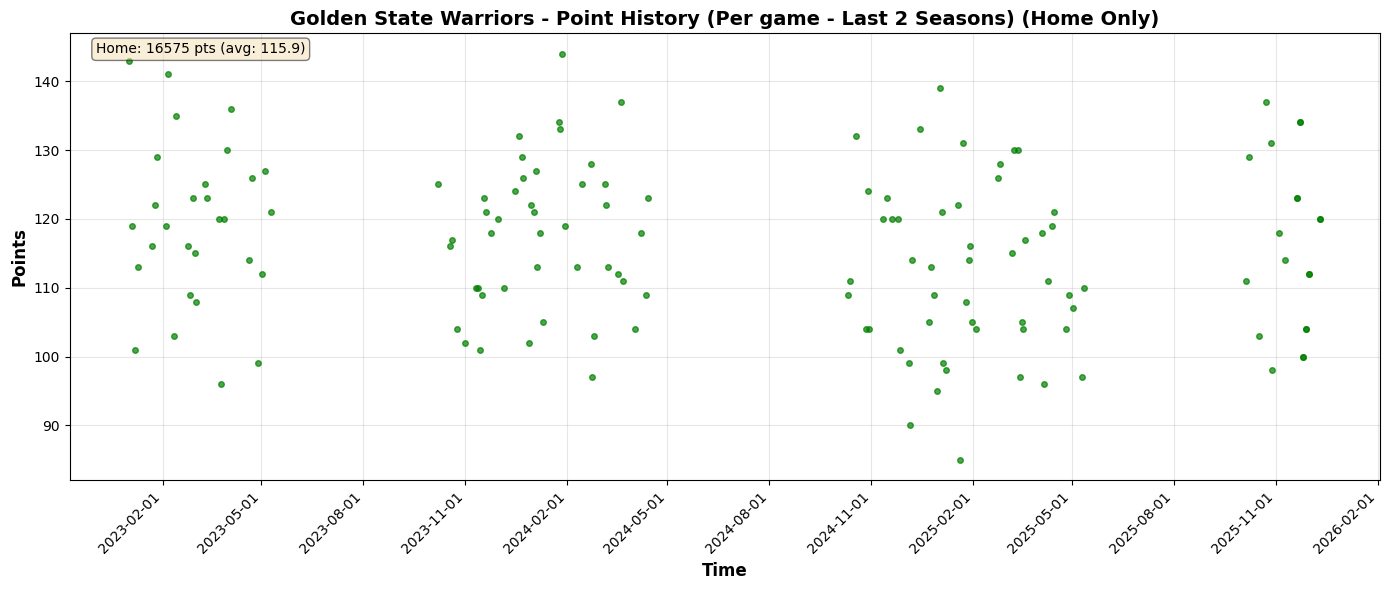

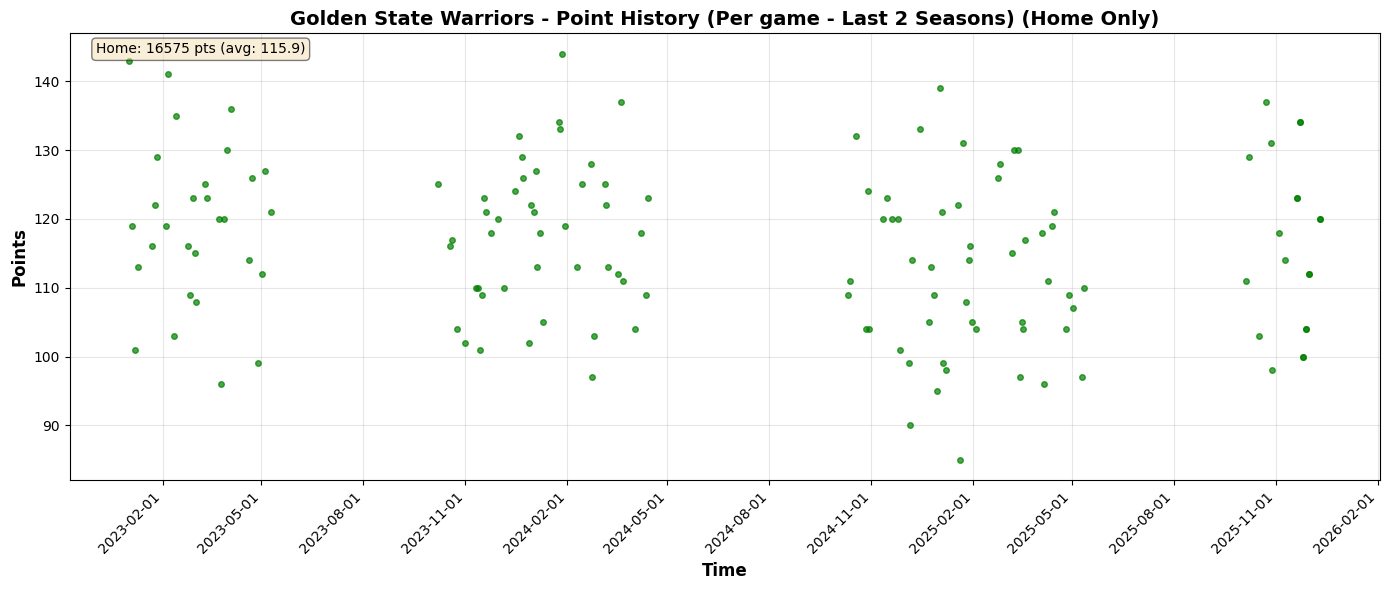

In [6]:
# Example: Warriors - last 2 seasons, home games only
get_team_point_history("Warriors", 2, games_per_point=1, show_home=True, show_away=False)

## Player Stat History

Visualize various player statistics (points, rebounds, assists, 3-pointers, blocks) over their last N games.

In [7]:
def get_stat_history(player, stat, num_past_games):
    """
    Generate a graph and summary of a player's statistics for a specific stat over their last N games.
    
    Parameters:
    -----------
    player : str
        Player name to search for (first name, last name, or full name)
    stat : str
        The stat to retrieve - one of: "points", "rebounds", "assists", "3_pointers", "blocks"
    num_past_games : int
        Number of most recent games to retrieve (e.g., 10, 20, 82)
    
    Returns:
    --------
    matplotlib figure showing the stat history and summary statistics
    """
    
    # Validate stat parameter
    valid_stats = ["points", "rebounds", "assists", "3_pointers", "blocks"]
    if stat not in valid_stats:
        print(f"Error: stat must be one of {valid_stats}")
        return None
    
    # Map stat parameter to DataFrame column name
    stat_column_map = {
        "points": "points",
        "rebounds": "reboundsTotal",
        "assists": "assists",
        "3_pointers": "threePointersMade",
        "blocks": "blocks"
    }
    
    stat_column = stat_column_map[stat]
    stat_display_name = stat.replace("_", " ").title()
    
    # Create a full name column for searching
    players_with_fullname = players_df.withColumn(
        "fullName", 
        concat(col("firstName"), lit(" "), col("lastName"))
    )
    
    # Get player ID
    player_info = players_with_fullname.filter(
        (col("firstName").like(f"%{player}%")) | 
        (col("lastName").like(f"%{player}%")) |
        (col("fullName").like(f"%{player}%"))
    ).first()
    
    if not player_info:
        print(f"Player '{player}' not found in database.")
        return None
    
    player_id = player_info["personId"]
    player_name = f"{player_info['firstName']} {player_info['lastName']}"
    
    print(f"Found player: {player_name} (ID: {player_id})")
    
    # Filter player statistics
    if stat == "rebounds":
        player_games = player_stats_df.filter(col("personId") == player_id) \
            .select("gameDate", stat_column, "numMinutes", "home", 
                   "reboundsOffensive", "reboundsDefensive")
    elif stat == "3_pointers":
        player_games = player_stats_df.filter(col("personId") == player_id) \
            .select("gameDate", stat_column, "numMinutes", "home", 
                   "threePointersAttempted")
    elif stat == "points":
        player_games = player_stats_df.filter(col("personId") == player_id) \
            .select("gameDate", stat_column, "numMinutes", "home", 
                   "fieldGoalsMade", "fieldGoalsAttempted", 
                   "freeThrowsMade", "freeThrowsAttempted")
    else:
        player_games = player_stats_df.filter(col("personId") == player_id) \
            .select("gameDate", stat_column, "numMinutes", "home")
    
    # Convert numMinutes to decimal format
    player_games = player_games.withColumn(
        "minutes_decimal",
        when(col("numMinutes").contains(":"),
             split(col("numMinutes"), ":")[0].cast("double") + 
             (split(col("numMinutes"), ":")[1].cast("double") / 60)
        ).otherwise(col("numMinutes").cast("double"))
    )
    
    # Convert gameDate to date type
    player_games = player_games.withColumn("gameDate", to_date(col("gameDate")))
    
    # Filter out games where player didn't play
    player_games = player_games.filter(
        (col("minutes_decimal").isNotNull()) & 
        (col("minutes_decimal") > 0) &
        (col(stat_column).isNotNull())
    )
    
    # Order by date (most recent first) and take N games
    player_games = player_games.orderBy(col("gameDate").desc()).limit(num_past_games)
    
    # Re-order chronologically for display
    player_games = player_games.orderBy("gameDate")
    
    # Convert to Pandas
    df = player_games.toPandas()
    
    if df.empty:
        print(f"No data found for {player_name} for {stat_display_name}.")
        return None
    
    print(f"Found {len(df)} games for {player_name}")
    
    # Calculate summary statistics
    total_stat = df[stat_column].sum()
    avg_stat = df[stat_column].mean()
    max_stat = df[stat_column].max()
    min_stat = df[stat_column].min()
    avg_minutes = df["minutes_decimal"].mean()
    
    # Print summary
    print(f"\n{stat_display_name} Summary (Last {len(df)} games):")
    print(f"  Total: {int(total_stat)}")
    print(f"  Average: {avg_stat:.1f} per game")
    print(f"  Max: {int(max_stat)}")
    print(f"  Min: {int(min_stat)}")
    print(f"  Avg Minutes: {avg_minutes:.1f}")
    
    # Additional stat-specific details
    if stat == "rebounds":
        total_off = df["reboundsOffensive"].sum()
        total_def = df["reboundsDefensive"].sum()
        print(f"  Offensive Rebounds: {int(total_off)} (avg: {total_off/len(df):.1f})")
        print(f"  Defensive Rebounds: {int(total_def)} (avg: {total_def/len(df):.1f})")
    elif stat == "3_pointers":
        total_attempts = df["threePointersAttempted"].sum()
        pct = (total_stat / total_attempts * 100) if total_attempts > 0 else 0
        print(f"  3PT Attempts: {int(total_attempts)} (avg: {total_attempts/len(df):.1f})")
        print(f"  3PT Percentage: {pct:.1f}%")
    elif stat == "points":
        total_fg = df["fieldGoalsMade"].sum()
        total_fg_att = df["fieldGoalsAttempted"].sum()
        total_ft = df["freeThrowsMade"].sum()
        total_ft_att = df["freeThrowsAttempted"].sum()
        fg_pct = (total_fg / total_fg_att * 100) if total_fg_att > 0 else 0
        ft_pct = (total_ft / total_ft_att * 100) if total_ft_att > 0 else 0
        print(f"  FG%: {fg_pct:.1f}% ({int(total_fg)}/{int(total_fg_att)})")
        print(f"  FT%: {ft_pct:.1f}% ({int(total_ft)}/{int(total_ft_att)})")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Separate by home/away for different colors
    home_df = df[df["home"] == 1]
    away_df = df[df["home"] == 0]
    
    # Plot home and away games with different markers
    if not home_df.empty:
        ax.plot(home_df['gameDate'], home_df[stat_column], 
               marker='o', markersize=6, linestyle='-', alpha=0.7, 
               label='Home', color='blue', linewidth=1.5)
    
    if not away_df.empty:
        ax.plot(away_df['gameDate'], away_df[stat_column], 
               marker='s', markersize=6, linestyle='-', alpha=0.7, 
               label='Away', color='red', linewidth=1.5)
    
    # Add average line
    ax.axhline(y=avg_stat, color='green', linestyle='--', linewidth=2, 
              label=f'Average ({avg_stat:.1f})', alpha=0.7)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')
    
    ax.legend(loc='upper right')
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel(stat_display_name, fontsize=12, fontweight='bold')
    ax.set_title(f'{player_name} - {stat_display_name} History (Last {len(df)} Games)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("Function 'get_stat_history' is now available!")

Function 'get_stat_history' is now available!


### Player Stat History Examples

Found player: Stephen Curry (ID: 201939)
Found 15 games for Stephen Curry

3 Pointers Summary (Last 15 games):
  Total: 77
  Average: 5.1 per game
  Max: 12
  Min: 1
  Avg Minutes: 31.1
  3PT Attempts: 191 (avg: 12.7)
  3PT Percentage: 40.3%


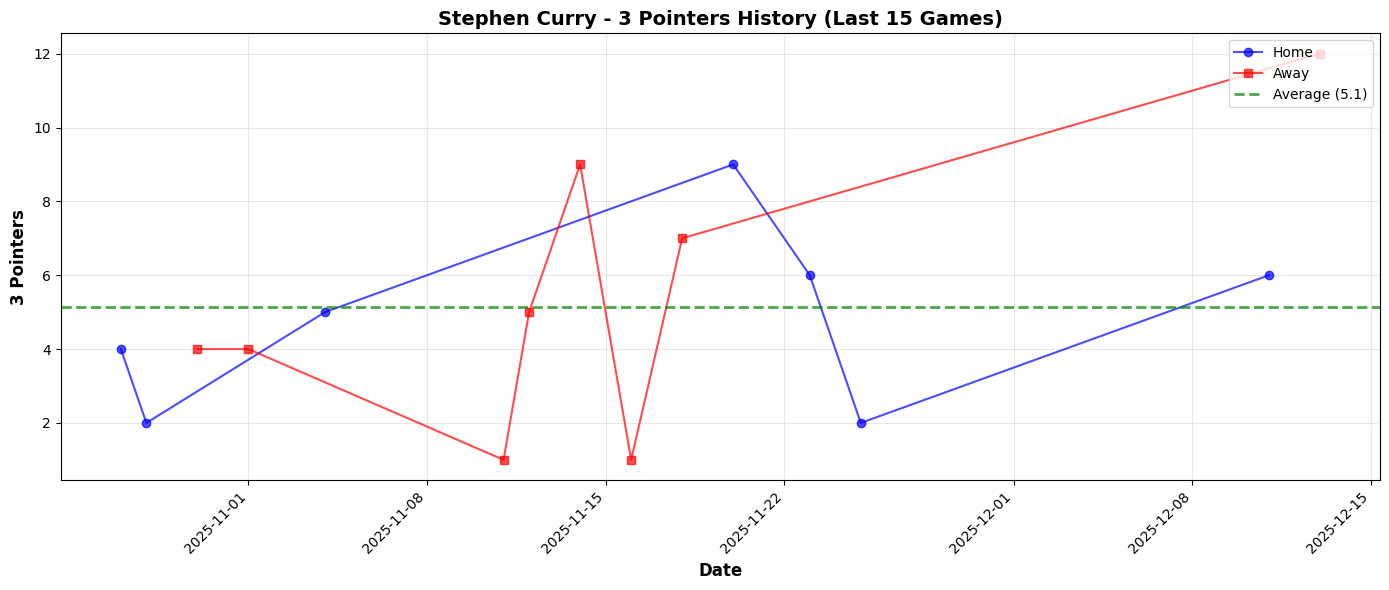

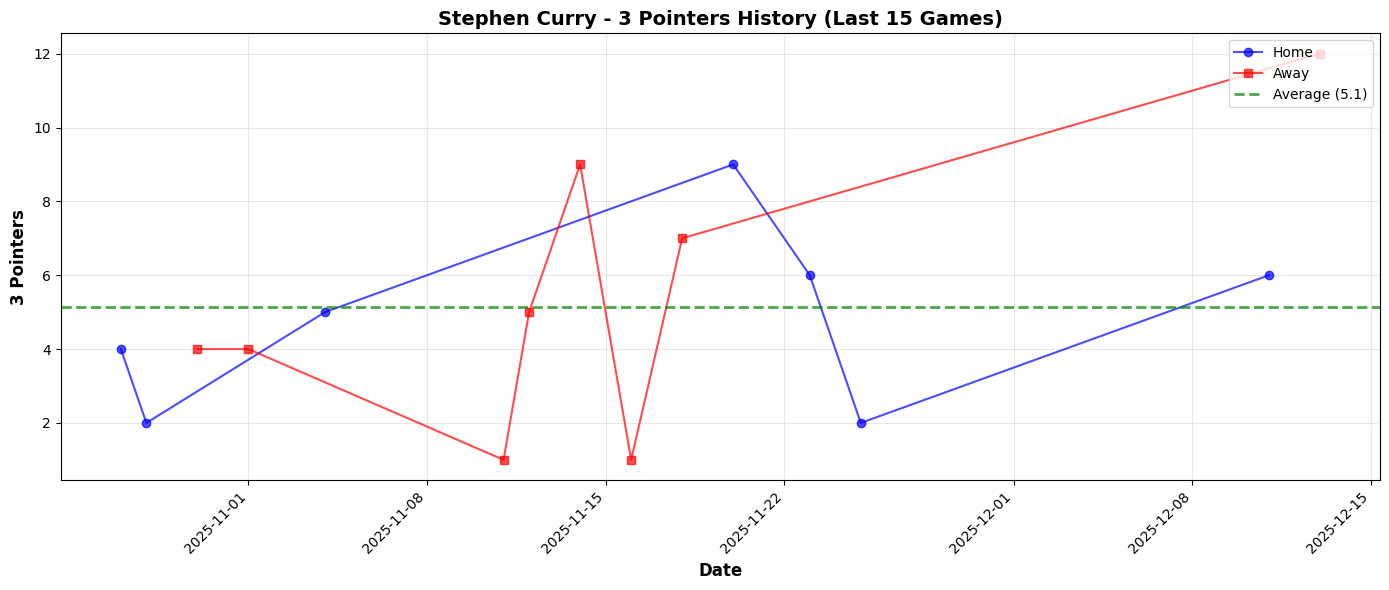

In [8]:
# Example: Stephen Curry's 3-pointers in his last 15 games
get_stat_history("Stephen Curry", "3_pointers", 15)